## Imports e configuração

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.measure import regionprops

%matplotlib inline

BASE_DIR      = Path("..")
PATH_PROCESSED = BASE_DIR / "data" / "processed"
PATH_IMAGES   = BASE_DIR / "data" / "raw" / "BBBC020_v1_images"
PATH_GT_CELLS = BASE_DIR / "data" / "processed" / "01_ground_truth" / "gt_cells"
PATH_FILT     = PATH_PROCESSED / "02_filtered_images"

FILTROS = ["mediana", "gaussiano", "fft"]   # os 3 candidatos salvos no Notebook 02

# Carregar manifesto de imagens com ground truth e metricas de filtragem
with open(BASE_DIR / "data" / "metadata" / "ground_truth_manifest.json") as f:
    MANIFEST = json.load(f)

df_filt = pd.read_csv(BASE_DIR / "data" / "metadata" / "metricas_filtragem.csv")
MELHOR_FILTRO = {}
for _, row in df_filt.iterrows():
    if row["melhor_filtro"]:
        MELHOR_FILTRO[row["imagem"]] = row["filtro"]


# -- Pre-processamento --------------------------------------------------------
def _carregar_c1(img_id):
    for f in (PATH_IMAGES / img_id).glob("*_c1.TIF"):
        return cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    return None

def _clahe(img):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)

def _fft_lp(img, raio=50):
    f = np.fft.fft2(img.astype(np.float64))
    fshift = np.fft.fftshift(f)
    H, W = img.shape
    Y, X = np.ogrid[:H, :W]
    mask = ((X - W // 2) ** 2 + (Y - H // 2) ** 2) <= raio ** 2
    result = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask)))
    return np.clip(result, 0, 255).astype(np.uint8)

def _load_filt(img_id, filtro):
    """Carrega a imagem filtrada (.npy) gerada pelo Notebook 02."""
    p = PATH_FILT / filtro / f"{img_id}.npy"
    return np.load(str(p)) if p.exists() else None


# -- Deteccao de bordas -------------------------------------------------------
def _sobel(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx ** 2 + sy ** 2)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def _laplaciano(img):
    lap = np.abs(cv2.Laplacian(img, cv2.CV_64F))
    return cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


# -- Segmentacao --------------------------------------------------------------
def _watershed(img, min_distance=15, fuse_thresh=0.5, sigma_mask=20, close_ksize=7):
    from scipy import ndimage as ndi
    from skimage.feature import peak_local_max
    from skimage.measure import regionprops

    # 1. Mascara: sigma grande preenche interior escuro das celulas
    img_blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_mask)
    _, binary = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # FECHAMENTO morfologico: fecha falhas no anel da membrana e pequenos vaos
    # (etapa prometida na proposta; limpa a mascara antes de separar com watershed)
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    binary  = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k_close)

    # Preenchimento do interior + abertura leve (remove respingos isolados)
    binary = ndi.binary_fill_holes(binary.astype(bool)).astype(np.uint8) * 255
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k3)

    # 2. Gradiente do original - usado como relevo E na fusao (calculado uma vez)
    img_g = cv2.GaussianBlur(img, (0, 0), sigmaX=1.5)
    gx = cv2.Sobel(img_g, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_g, cv2.CV_64F, 0, 1, ksize=3)
    gradient = cv2.normalize(
        np.sqrt(gx**2 + gy**2), None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # 3. Distancia transform da mascara preenchida -> picos no centro de cada celula
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    dist_smooth = cv2.GaussianBlur(dist, (0, 0), sigmaX=5)

    # 4. Sementes: um pico por celula
    coords = peak_local_max(dist_smooth, min_distance=min_distance, threshold_rel=0.1)
    local_max = np.zeros(dist.shape, dtype=bool)
    if len(coords):
        local_max[coords[:, 0], coords[:, 1]] = True
    local_max &= binary.astype(bool)
    seed_labels, _ = ndi.label(local_max)

    # 5. Marcadores
    markers = np.zeros(img.shape, dtype=np.int32)
    markers[seed_labels > 0] = seed_labels[seed_labels > 0] + 1
    markers[binary == 0] = 1   # fora da mascara = fundo

    # 6. Watershed: relevo = gradiente (membrana brilhante = barreira natural)
    relief = cv2.merge([gradient, gradient, gradient])
    markers = cv2.watershed(relief, markers)

    # 7. Fusao de fragmentos com borda fraca
    labels = markers.copy().astype(np.int32)
    labels[(labels <= 1) | (labels == -1)] = 0
    strong_edge = gradient > int(fuse_thresh * 255)

    for region in sorted(regionprops(labels), key=lambda r: r.area, reverse=True):
        lbl = region.label
        if lbl <= 1:
            continue
        dil = cv2.dilate((labels == lbl).astype(np.uint8), np.ones((3, 3), np.uint8))
        for adj in np.unique(labels[dil > 0]):
            if adj <= 1 or adj == lbl:
                continue
            border = (dil > 0) & (labels == adj)
            if border.any() and strong_edge[border].mean() < 0.3:
                labels[labels == adj] = lbl

    # 8. Filtro area + re-rotulacao
    unique_lbls = [u for u in np.unique(labels) if u > 1]
    if unique_lbls:
        areas    = np.array([np.sum(labels == u) for u in unique_lbls])
        min_area = max(300, np.median(areas) / 4)
        valid    = [u for u, a in zip(unique_lbls, areas) if a >= min_area]
    else:
        valid = []

    new_labels = np.ones_like(labels, dtype=np.int32)
    for i, u in enumerate(valid, start=2):
        new_labels[labels == u] = i
    new_labels[markers == -1] = -1

    return new_labels, len(valid)

def _colorir_watershed(markers):
    rng = np.random.default_rng(42)
    vis = np.zeros((*markers.shape, 3), dtype=np.uint8)
    for label in np.unique(markers):
        if label <= 1:
            continue
        vis[markers == label] = rng.integers(60, 240, 3)
    vis[markers == -1] = [220, 50, 50]   # bordas em vermelho
    return vis


# -- Ground Truth -------------------------------------------------------------
def _gt_count(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return int(np.load(str(p)).max()) if p.exists() else None

def _gt_binary(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return (np.load(str(p)) > 0).astype(np.uint8) if p.exists() else None

def _cell_level_metrics(pred_labels, gt_labels, iou_thresh=0.5):
    """TP, FP, FN comparando mascaras rotuladas de celulas individuais (IoU>thresh)."""
    pred_cells = [l for l in np.unique(pred_labels) if l > 1]
    gt_cells   = [l for l in np.unique(gt_labels) if l > 0]
    matched_gt = set()
    tp = 0
    fp = 0
    for p in pred_cells:
        mask_p = (pred_labels == p)
        best_iou = 0
        best_gt = None
        for g in gt_cells:
            if g in matched_gt:
                continue
            mask_g = (gt_labels == g)
            inter = np.logical_and(mask_p, mask_g).sum()
            union = np.logical_or(mask_p, mask_g).sum()
            iou = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou = iou
                best_gt = g
        if best_iou > iou_thresh and best_gt is not None:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1
    fn = len(gt_cells) - len(matched_gt)
    return tp, fp, fn


# -- Carregamento -------------------------------------------------------------
dict_imgs  = {p.name: _carregar_c1(p.name) for p in sorted(PATH_IMAGES.iterdir()) if p.is_dir()}
dict_imgs  = {k: v for k, v in dict_imgs.items() if v is not None}
ids_com_gt = [k for k in dict_imgs if _gt_count(k) is not None]

ID_EX  = ids_com_gt[0]
IMG_EX = dict_imgs[ID_EX]
print(f"{len(dict_imgs)} imagens | {len(ids_com_gt)} com GT | exemplo: '{ID_EX}'")
print(f"shape={IMG_EX.shape} | GT celulas={_gt_count(ID_EX)}")


25 imagens | 20 com GT | exemplo: 'jw-15min 1'
shape=(1040, 1388) | GT celulas=29


## 2. Detecção de Bordas — Sobel, Laplaciano e o impacto de cada filtro

Dois papéis distintos das bordas neste pipeline:

- **Sobel (magnitude do gradiente) É USADO na segmentação.** Na Seção 3 ele é o
  *relevo* sobre o qual o Watershed "escorre": a membrana brilhante das células
  vira uma crista de gradiente que funciona como barreira natural entre células
  vizinhas. Ou seja, a detecção de bordas está integrada ao resultado — não é
  decorativa. (As *sementes* do Watershed vêm da transformada de distância, que
  isola o centro de cada célula; o gradiente define as *fronteiras*.)
- **Laplaciano (|∇²I|)** é mostrado para comparação didática — realça transições
  finas, mas é muito sensível a ruído.

Aqui também entregamos o que a proposta pediu: **como cada filtro afeta a qualidade
das bordas**. Aplicamos Sobel/Laplaciano às três versões filtradas (mediana,
gaussiano, FFT) e medimos, usando o gabarito, o **contraste de borda** = gradiente
médio sobre as bordas reais das células ÷ gradiente médio no fundo. Quanto maior,
melhor o filtro preservou as bordas verdadeiras enquanto suprimiu bordas espúrias
do ruído.


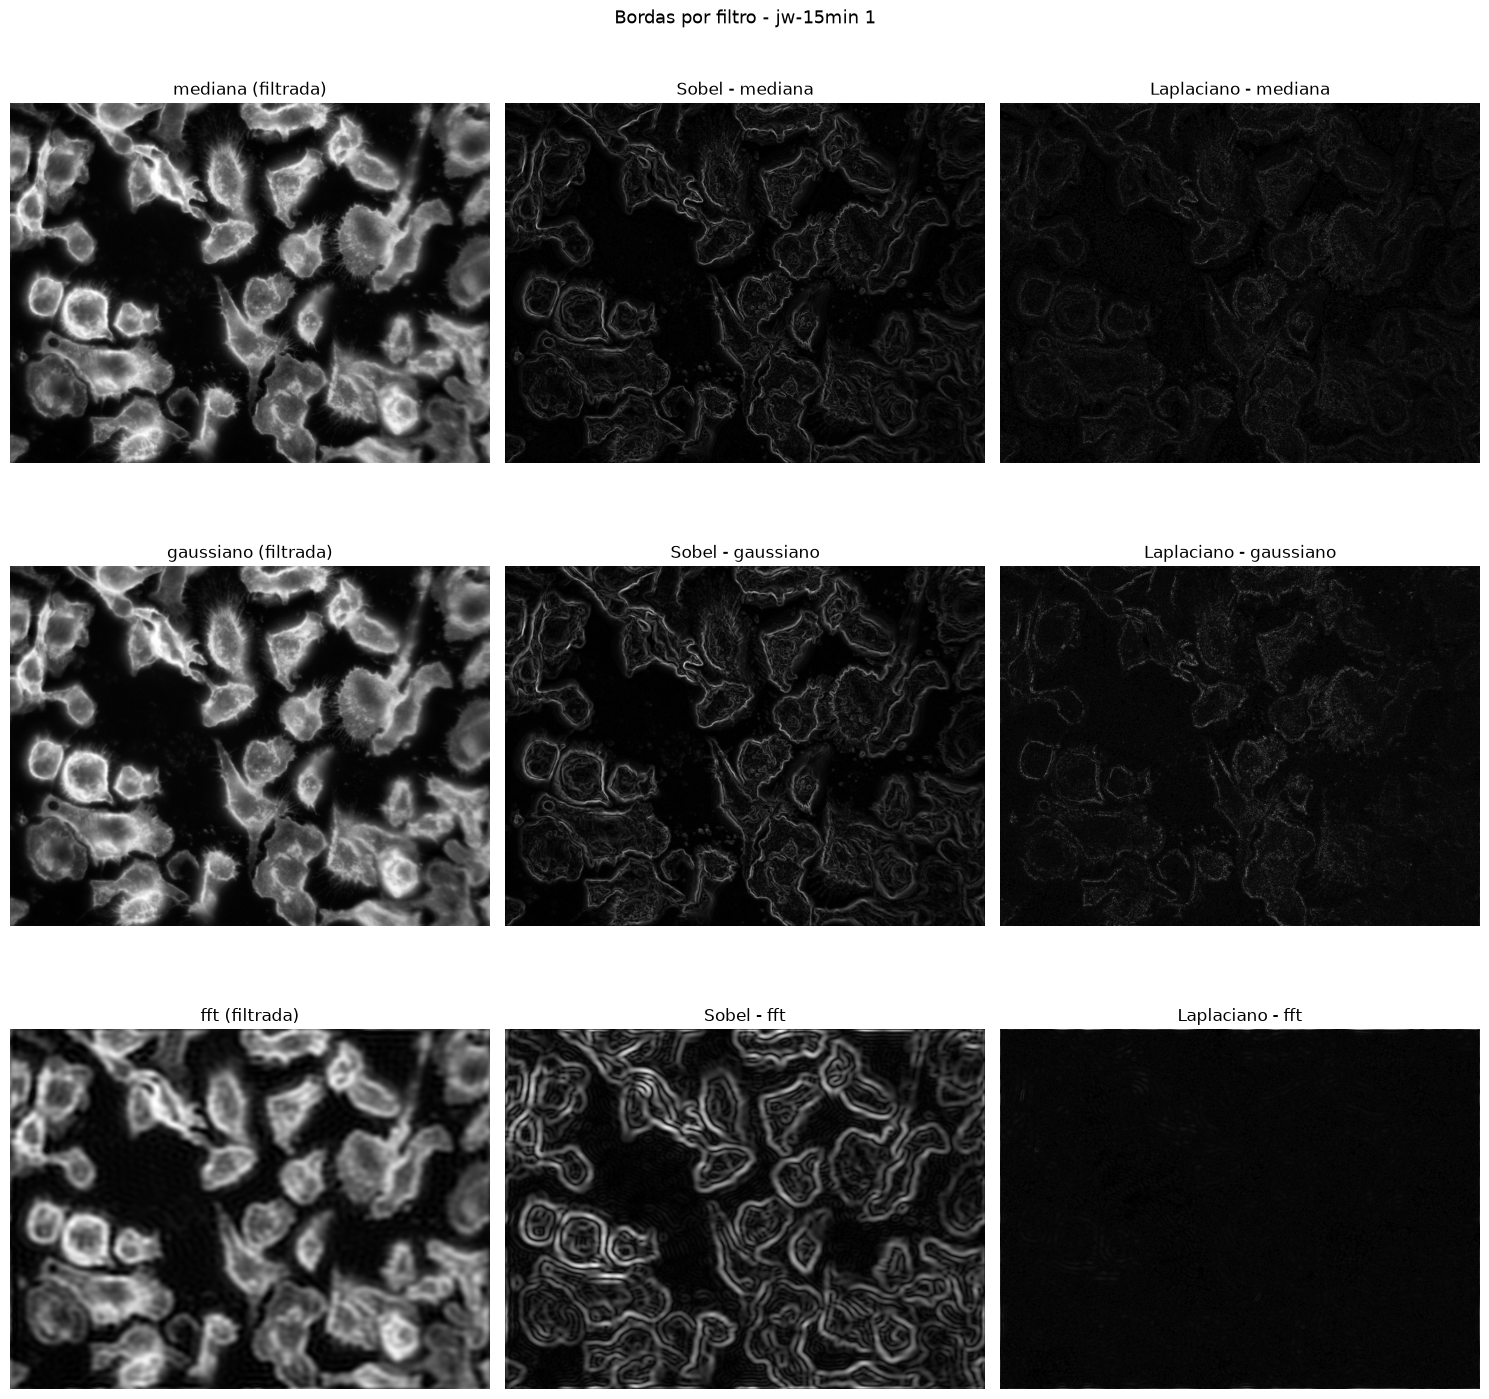

In [2]:
# Carrega as 3 versoes filtradas da imagem-exemplo (geradas no Notebook 02)
filt_ex = {f: _load_filt(ID_EX, f) for f in FILTROS}
faltando = [f for f, v in filt_ex.items() if v is None]
if faltando:
    print("Versoes filtradas ausentes:", faltando, "-> rode o Notebook 02 antes.")

fig, axes = plt.subplots(len(FILTROS), 3, figsize=(15, 5 * len(FILTROS)))
for row, f in zip(axes, FILTROS):
    img_f = filt_ex[f]
    if img_f is None:
        for ax in row:
            ax.axis('off')
        continue
    for ax, (im, cmap, t) in zip(row, [
        (img_f,              'gray', f"{f} (filtrada)"),
        (_sobel(img_f),      'gray', f"Sobel - {f}"),
        (_laplaciano(img_f), 'gray', f"Laplaciano - {f}"),
    ]):
        ax.imshow(im, cmap=cmap)
        ax.set_title(t)
        ax.axis('off')
plt.suptitle(f"Bordas por filtro - {ID_EX}", fontsize=13)
plt.tight_layout()
plt.show()


In [3]:
def _contraste_borda(edge_map, gt_bin):
    """Forca media do gradiente sobre as bordas reais do GT / forca no fundo."""
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    gt_u = gt_bin.astype(np.uint8)
    borda_gt = (gt_u - cv2.erode(gt_u, k3)) > 0   # contorno das celulas do gabarito
    fundo    = gt_bin == 0
    e = edge_map.astype(np.float64)
    f_borda = e[borda_gt].mean() if borda_gt.any() else np.nan
    f_fundo = e[fundo].mean()    if fundo.any()    else np.nan
    contraste = (f_borda / f_fundo) if (f_fundo and f_fundo > 0) else np.nan
    return f_borda, f_fundo, contraste

# Agrega sobre todas as imagens com GT
linhas = []
for img_id in MANIFEST:
    gt = _gt_binary(img_id)
    if gt is None:
        continue
    for f in FILTROS:
        im = _load_filt(img_id, f)
        if im is None:
            continue
        b, fundo, contr = _contraste_borda(_sobel(im), gt)
        linhas.append({"filtro": f, "borda": b, "fundo": fundo, "contraste": contr})

df_edge = pd.DataFrame(linhas)
if not df_edge.empty:
    n_imgs = int(df_edge["filtro"].value_counts().iloc[0])
    resumo_edge = (df_edge.groupby("filtro")[["borda", "fundo", "contraste"]]
                   .mean().sort_values("contraste", ascending=False))
    print(f"=== Qualidade de borda por filtro (Sobel, media sobre {n_imgs} imagens) ===")
    print("borda: gradiente medio nas bordas reais (^) | fundo: gradiente medio no fundo (v)")
    print("contraste = borda/fundo (^ melhor)\n")
    print(resumo_edge.round(2).to_string())
else:
    print("Sem dados para analise de borda (verifique 02_filtered_images e o GT).")


=== Qualidade de borda por filtro (Sobel, media sobre 20 imagens) ===
borda: gradiente medio nas bordas reais (^) | fundo: gradiente medio no fundo (v)
contraste = borda/fundo (^ melhor)

           borda  fundo  contraste
filtro                            
gaussiano  49.89  15.38       3.46
mediana    38.39  12.10       3.35
fft        77.36  31.84       2.62


## 3. Segmentação via Watershed — Etapas Intermediárias

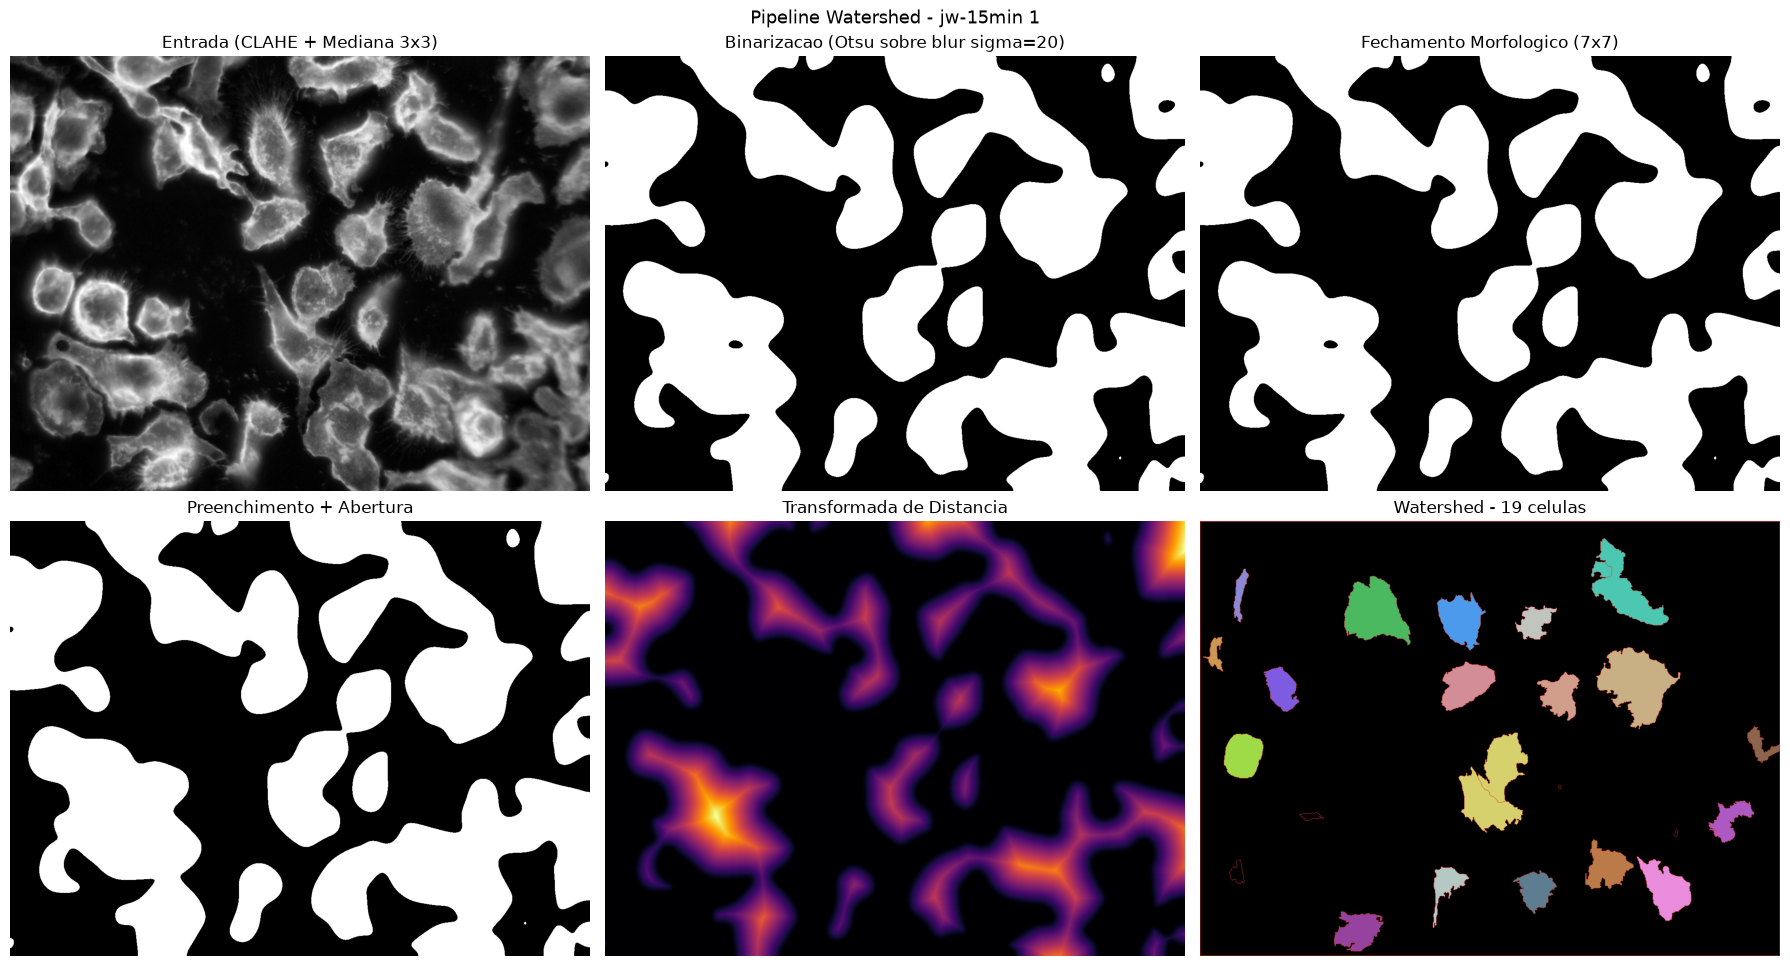

In [4]:
# Reproduz visualmente as etapas internas de _watershed (mesma sequencia, incl. fechamento)
img_proc = _load_filt(ID_EX, "mediana")
if img_proc is None:
    img_proc = cv2.medianBlur(_clahe(IMG_EX), 3)   # fallback consistente com o Notebook 02

img_blur       = cv2.GaussianBlur(img_proc, (0, 0), sigmaX=20)
_, binary_otsu = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
k_close        = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
binary_closed  = cv2.morphologyEx(binary_otsu, cv2.MORPH_CLOSE, k_close)
binary_filled  = ndi.binary_fill_holes(binary_closed.astype(bool)).astype(np.uint8) * 255
k3             = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary_open    = cv2.morphologyEx(binary_filled, cv2.MORPH_OPEN, k3)
dist           = cv2.distanceTransform(binary_open, cv2.DIST_L2, 5)

markers_ex, n_ex = _watershed(img_proc)
vis_ex           = _colorir_watershed(markers_ex)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (img, cmap, t) in zip(axes.ravel(), [
    (img_proc,      'gray',    "Entrada (CLAHE + Mediana 3x3)"),
    (binary_otsu,   'gray',    "Binarizacao (Otsu sobre blur sigma=20)"),
    (binary_closed, 'gray',    "Fechamento Morfologico (7x7)"),
    (binary_open,   'gray',    "Preenchimento + Abertura"),
    (dist,          'inferno', "Transformada de Distancia"),
    (vis_ex,        None,      f"Watershed - {n_ex} celulas"),
]):
    ax.imshow(img, cmap=cmap)
    ax.set_title(t)
    ax.axis('off')
plt.suptitle(f"Pipeline Watershed - {ID_EX}", fontsize=13)
plt.tight_layout()
plt.show()


## 4. Contagem e Validação

In [5]:
gt_n   = _gt_count(ID_EX)
gt_bin = _gt_binary(ID_EX)
pred_bin = (markers_ex > 1).astype(np.uint8)

inter = np.logical_and(pred_bin, gt_bin).sum()
union = np.logical_or(pred_bin, gt_bin).sum()
iou   = inter / union if union > 0 else 0.0

erro_abs  = abs(n_ex - gt_n)
erro_perc = erro_abs / gt_n * 100 if gt_n > 0 else float('nan')

print(f"=== Validação — {ID_EX} ===")
print(f"Detectadas  : {n_ex}")
print(f"Gabarito    : {gt_n}")
print(f"Erro abs.   : {erro_abs}")
print(f"Erro rel.   : {erro_perc:.1f}%")
print(f"IoU binária : {iou:.4f}")

=== Validação — jw-15min 1 ===
Detectadas  : 19
Gabarito    : 29
Erro abs.   : 10
Erro rel.   : 34.5%
IoU binária : 0.2809


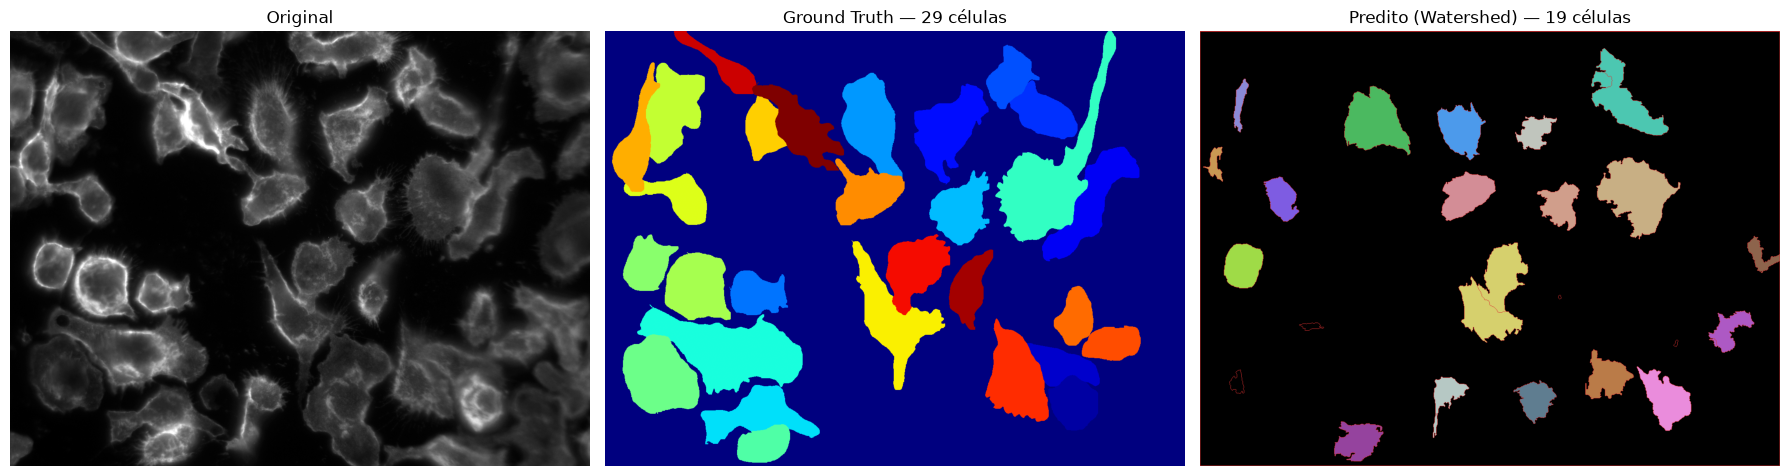

In [6]:
gt_labeled = np.load(str(PATH_GT_CELLS / f"{ID_EX}_gt_cells.npy"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (img, cmap, t) in zip(axes, [
    (IMG_EX,    'gray', "Original"),
    (gt_labeled, 'jet', f"Ground Truth — {gt_n} células"),
    (vis_ex,     None,  f"Predito (Watershed) — {n_ex} células"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Comparação de Pipelines — qual combinação conta melhor

A proposta pede demonstrar **qual combinação de técnicas entrega o melhor resultado
final**. Qualidade de imagem (PSNR, no Notebook 02) **não** é o árbitro correto: um
filtro que borra demais pode *fundir* células que se tocam e piorar a contagem,
mesmo com PSNR alto. Por isso rodamos os **três** filtros (mediana, gaussiano, FFT)
pelo mesmo Watershed e comparamos contra o gabarito usando o que de fato importa:
**erro de contagem**, **IoU** e **F1 por célula** (TP/FP/FN com IoU>0,5).


In [7]:
# Saida para as mascaras segmentadas, uma subpasta por filtro
out_masks = PATH_PROCESSED / "03_segmented_masks"
for f in FILTROS:
    (out_masks / f).mkdir(parents=True, exist_ok=True)

registros_cmp = []
for img_id in MANIFEST:
    gt_path = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    if not gt_path.exists():
        continue
    gt_labeled = np.load(str(gt_path))
    gt_n   = int(gt_labeled.max())
    gt_bin = (gt_labeled > 0).astype(np.uint8)

    for f in FILTROS:
        img_filt = _load_filt(img_id, f)
        if img_filt is None:
            print(f"Filtrada ausente: {img_id}/{f} - pulando")
            continue

        markers, n_det = _watershed(img_filt)
        np.save(out_masks / f / f"{img_id}.npy", markers)

        erro_abs  = abs(n_det - gt_n)
        erro_perc = erro_abs / gt_n * 100 if gt_n > 0 else np.nan
        pred_bin  = (markers > 1).astype(np.uint8)
        inter = np.logical_and(pred_bin, gt_bin).sum()
        union = np.logical_or(pred_bin, gt_bin).sum()
        iou   = inter / union if union > 0 else 0.0
        tp, fp, fn = _cell_level_metrics(markers, gt_labeled)

        registros_cmp.append({
            "imagem": img_id, "filtro": f,
            "detectado": n_det, "gabarito": gt_n,
            "erro_abs": erro_abs, "erro_perc": round(erro_perc, 2),
            "iou": round(iou, 4), "tp": tp, "fp": fp, "fn": fn,
        })

df_cmp = pd.DataFrame(registros_cmp)
csv_cmp = BASE_DIR / "data" / "metadata" / "metricas_comparacao_pipelines.csv"
df_cmp.to_csv(csv_cmp, index=False)
print(f"Metricas por (imagem, filtro) salvas em {csv_cmp}")
print(f"Linhas: {len(df_cmp)} | imagens: {df_cmp['imagem'].nunique()} | filtros: {FILTROS}")
df_cmp.head(9)


Metricas por (imagem, filtro) salvas em ../data/metadata/metricas_comparacao_pipelines.csv
Linhas: 60 | imagens: 20 | filtros: ['mediana', 'gaussiano', 'fft']


,imagem,filtro,detectado,gabarito,erro_abs,erro_perc,iou,tp,fp,fn
0,jw-15min 1,mediana,19,29,10,34.48,0.2809,4,15,25
1,jw-15min 1,gaussiano,20,29,9,31.03,0.2512,3,17,26
2,jw-15min 1,fft,17,29,12,41.38,0.2022,3,14,26
3,jw-15min 2,mediana,13,24,11,45.83,0.1914,4,9,20
4,jw-15min 2,gaussiano,12,24,12,50.00,0.1861,4,8,20
5,jw-15min 2,fft,15,24,9,37.50,0.1940,3,12,21
6,jw-15min 3,mediana,11,27,16,59.26,0.3347,5,6,22
7,jw-15min 3,gaussiano,14,27,13,48.15,0.3415,3,11,24
8,jw-15min 3,fft,12,27,15,55.56,0.2912,3,9,24


In [8]:
def _f1(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * p * r / (p + r)) if (p + r) else 0.0
    return f1, p, r

linhas = []
for f in FILTROS:
    sub = df_cmp[df_cmp["filtro"] == f]
    if sub.empty:
        continue
    TP, FP, FN = int(sub["tp"].sum()), int(sub["fp"].sum()), int(sub["fn"].sum())
    f1, prec, rec = _f1(TP, FP, FN)
    linhas.append({
        "filtro": f,
        "erro%_medio": round(sub["erro_perc"].mean(), 2),
        "erro_abs_medio": round(sub["erro_abs"].mean(), 2),
        "iou_medio": round(sub["iou"].mean(), 4),
        "precisao": round(prec, 3),
        "recall": round(rec, 3),
        "f1": round(f1, 3),
    })

df_resumo = pd.DataFrame(linhas).sort_values("f1", ascending=False).reset_index(drop=True)
print("=== Comparacao de pipelines (media sobre as imagens com GT) ===")
print(df_resumo.to_string(index=False))

vencedor = df_resumo.iloc[0]["filtro"]
print(f"\nMelhor pipeline por F1: {vencedor}")

# Contraste com a escolha do Notebook 02 (por PSNR)
psnr_escolha = pd.Series(MELHOR_FILTRO).value_counts()
print("\nFiltro escolhido por PSNR no Notebook 02 (por imagem):")
print(psnr_escolha.to_string() if not psnr_escolha.empty else "  (CSV de filtragem nao carregado)")
print("\nObs.: se o vencedor por CONTAGEM diferir do escolhido por PSNR, fica")
print("demonstrado que qualidade de imagem nao prediz qualidade de segmentacao.")


=== Comparacao de pipelines (media sobre as imagens com GT) ===
   filtro  erro%_medio  erro_abs_medio  iou_medio  precisao  recall    f1
  mediana        39.87            10.6     0.2543     0.318   0.188 0.236
gaussiano        38.26            10.3     0.2535     0.312   0.188 0.235
      fft        38.24            10.1     0.2193     0.227   0.140 0.173

Melhor pipeline por F1: mediana

Filtro escolhido por PSNR no Notebook 02 (por imagem):
gaussiano    20

Obs.: se o vencedor por CONTAGEM diferir do escolhido por PSNR, fica
demonstrado que qualidade de imagem nao prediz qualidade de segmentacao.


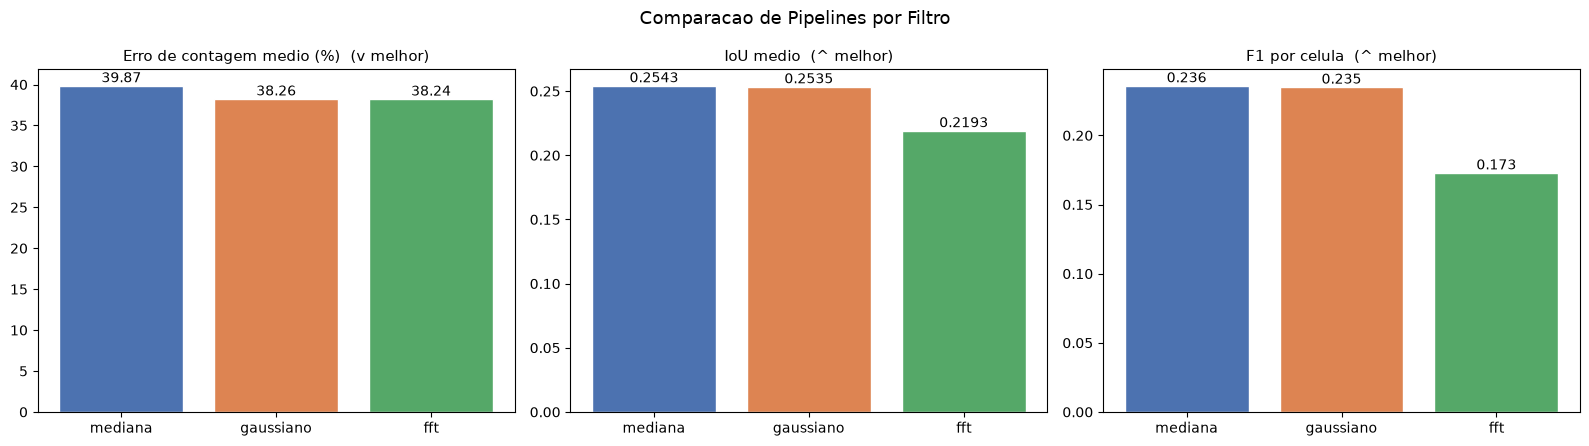

In [9]:
metricas = [("erro%_medio", "Erro de contagem medio (%)  (v melhor)"),
            ("iou_medio",   "IoU medio  (^ melhor)"),
            ("f1",          "F1 por celula  (^ melhor)")]
cores = {"mediana": "#4C72B0", "gaussiano": "#DD8452", "fft": "#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, titulo) in zip(axes, metricas):
    ax.bar(df_resumo["filtro"], df_resumo[col],
           color=[cores.get(f, "gray") for f in df_resumo["filtro"]], edgecolor="white")
    ax.set_title(titulo, fontsize=11)
    for i, v in enumerate(df_resumo[col]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=10)
plt.suptitle("Comparacao de Pipelines por Filtro", fontsize=13)
plt.tight_layout()
plt.show()


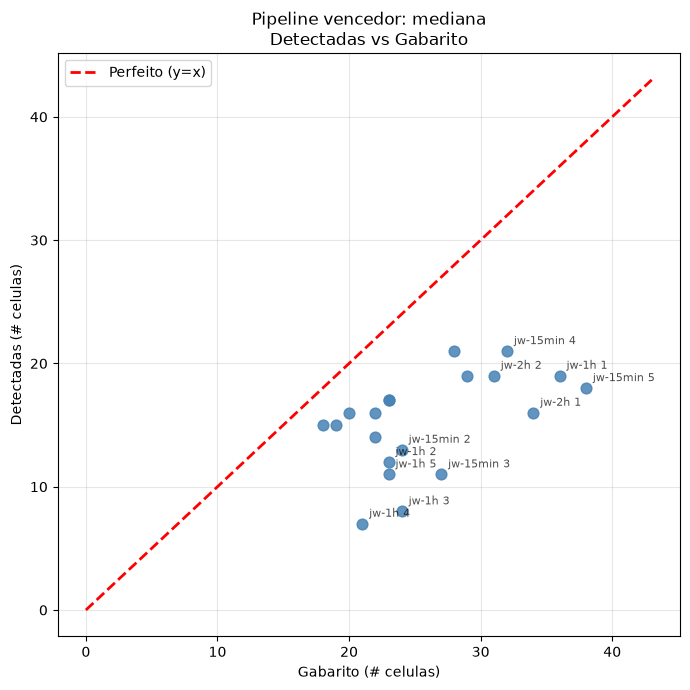

=== Conclusao ===
mediana   | erro  39.9% | IoU 0.254 | F1 0.236
gaussiano | erro  38.3% | IoU 0.254 | F1 0.235
fft       | erro  38.2% | IoU 0.219 | F1 0.173

Melhor combinacao final: CLAHE + mediana + Watershed (com fechamento).


In [11]:
sub_v = df_cmp[df_cmp["filtro"] == vencedor]

fig, ax = plt.subplots(figsize=(7, 7))
max_val = max(sub_v["gabarito"].max(), sub_v["detectado"].max()) + 5
ax.scatter(sub_v["gabarito"], sub_v["detectado"], s=60, alpha=0.85, color="steelblue", zorder=3)
ax.plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfeito (y=x)")
for _, row in sub_v.iterrows():
    if abs(row["detectado"] - row["gabarito"]) > sub_v["erro_abs"].mean():
        ax.annotate(row["imagem"], (row["gabarito"], row["detectado"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.7)
ax.set_xlabel("Gabarito (# celulas)")
ax.set_ylabel("Detectadas (# celulas)")
ax.set_title(f"Pipeline vencedor: {vencedor}\nDetectadas vs Gabarito")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Conclusao ===")
for _, r in df_resumo.iterrows():
    print(f"{r['filtro']:9s} | erro {r['erro%_medio']:5.1f}% | IoU {r['iou_medio']:.3f} | F1 {r['f1']:.3f}")
print(f"\nMelhor combinacao final: CLAHE + {vencedor} + Watershed (com fechamento).")